In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
print("="*35+'done'+'='*35)

===================================done===================================


In [3]:
print("Loading data")
print("="*80)
#Loading in data
file_path = r"C:\Users\kenne\Downloads\PWT11_clean_2019 (version 1).xlsb.xlsx"
EconometricData = pd.read_excel(file_path, sheet_name="Sheet3")
print (EconometricData.head())
print("="*35+'done'+'='*35)

Loading data
  countrycode               country  year          rgdpo        pop  \
0         ABW                 Aruba  2021    4026.352539   0.107558   
1         AGO                Angola  2021  215422.875000  34.532429   
2         AIA              Anguilla  2021     268.632935   0.014475   
3         ALB               Albania  2021   42296.042969   2.849635   
4         ARE  United Arab Emirates  2021  711028.125000   9.789048   

         emp      avh        hc        ck      ctfp  rtfpna  
0   0.048457      NaN       NaN  0.000222       NaN     NaN  
1  16.094906  2067.72  1.507136  0.008424  0.485366     1.0  
2        NaN      NaN       NaN       NaN       NaN     NaN  
3   1.127748  2125.82  3.004053  0.001782  0.476835     1.0  
4   5.999405  2657.34  3.254923       NaN       NaN     NaN  
===================================done===================================


In [4]:
print ("data exploration")
print("="*80)

print("\nColumn information:")
print(EconometricData.info())
print("="*80)

print("\ndescribe information:")
print(EconometricData.info())
print("="*80)

print("\nColumn information:")
print(EconometricData.describe())
print("="*80)

print("\nMissing values:")
print(EconometricData.isnull().sum())
print("="*35+'done'+'='*35)

data exploration

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   countrycode  185 non-null    object 
 1   country      185 non-null    object 
 2   year         185 non-null    int64  
 3   rgdpo        185 non-null    float64
 4   pop          185 non-null    float64
 5   emp          179 non-null    float64
 6   avh          130 non-null    float64
 7   hc           145 non-null    float64
 8   ck           139 non-null    float64
 9   ctfp         120 non-null    float64
 10  rtfpna       120 non-null    float64
dtypes: float64(8), int64(1), object(2)
memory usage: 16.0+ KB
None

describe information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   countrycode  185 non-null 

In [5]:
print("Identifying Removed Countries")
print("="*80)

data_clean = EconometricData.dropna()

countries_before = EconometricData['country'].tolist()
country_codes_before = EconometricData['countrycode'].tolist()

print(f"Total countries before cleaning: {len(countries_before)}")


countries_after = data_clean['country'].tolist()
country_codes_after = data_clean['countrycode'].tolist()

print(f"Total countries after cleaning: {len(countries_after)}")
print(f"Countries removed: {len(countries_before) - len(countries_after)}")


removed_countries = set(countries_before) - set(countries_after)
removed_country_codes = set(country_codes_before) - set(country_codes_after)

print(f" REMOVED COUNTRIES ({len(removed_countries)}):")
print("="*80)


removed_list = []
for i, country in enumerate(EconometricData['country']):
    if country in removed_countries:
        code = EconometricData.iloc[i]['countrycode']
        removed_list.append((code, country))

removed_list = sorted(set(removed_list)) 
for i, (code, country) in enumerate(removed_list, 1):
    print(f"  {i:2d}. {code} - {country}")

print('#'*40)
removed_list = []
for i, country in enumerate(EconometricData['country']):
    if country in removed_countries:
        code = EconometricData.iloc[i]['country']
        removed_list.append((code, country))

removed_list = sorted(set(removed_list)) 

# list2
print(", ".join([f"{code}" for code, country in removed_list]))
print('#'*40)  
#
print("="*35+'done'+'='*35)

Identifying Removed Countries
Total countries before cleaning: 185
Total countries after cleaning: 103
Countries removed: 82
 REMOVED COUNTRIES (82):
   1. ABW - Aruba
   2. AIA - Anguilla
   3. ARE - United Arab Emirates
   4. ATG - Antigua and Barbuda
   5. AZE - Azerbaijan
   6. BDI - Burundi
   7. BEN - Benin
   8. BGD - Bangladesh
   9. BHS - Bahamas
  10. BIH - Bosnia and Herzegovina
  11. BLR - Belarus
  12. BLZ - Belize
  13. BMU - Bermuda
  14. BRB - Barbados
  15. BRN - Brunei Darussalam
  16. BTN - Bhutan
  17. CAF - Central African Republic
  18. COD - D.R. of the Congo
  19. COG - Congo
  20. COM - Comoros
  21. CPV - Cabo Verde
  22. CUW - Curaçao
  23. CYM - Cayman Islands
  24. DJI - Djibouti
  25. DMA - Dominica
  26. DZA - Algeria
  27. ETH - Ethiopia
  28. FJI - Fiji
  29. GEO - Georgia
  30. GHA - Ghana
  31. GIN - Guinea
  32. GMB - Gambia
  33. GNB - Guinea-Bissau
  34. GNQ - Equatorial Guinea
  35. GRD - Grenada
  36. GUY - Guyana
  37. HND - Honduras
  38. HTI -

In [7]:
feature_columns = ['rgdpo','pop', 'emp', 'avh' , 'hc', 'ck' ,'ctfp',]

print("List of Selected features:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i}. {col}")

X = data_clean[feature_columns].values
print(f"matrix shape: {X.shape}")

print("="*36+'done'+'='*36)

List of Selected features:
  1. rgdpo
  2. pop
  3. emp
  4. avh
  5. hc
  6. ck
  7. ctfp
matrix shape: (103, 7)
====================================done====================================


In [8]:
#Scaling data/features
print("="*80)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Using StandardScaler (mean=0, std=1):")
#print('')
print(f"  Mean: {scaler.mean_}")
print(f"  Std:  {scaler.scale_}")

#double check 
print(f"\nVerification:")
print(f"  Mean of scaled features: {X_scaled.mean(axis=0).round(10)}")
print(f"  Std of scaled features:  {X_scaled.std(axis=0).round(2)}")
# originally had 8 feutures however had to remove one due to indexing issue in data set.

Using StandardScaler (mean=0, std=1):
  Mean: [1.39195395e+06 6.28536442e+01 2.78529417e+01 1.89513282e+03
 2.94855341e+00 6.59677451e-02 6.58797592e-01]
  Std:  [3.84030926e+06 1.98951893e+02 9.42400134e+01 2.98723770e+02
 6.22591715e-01 1.77919676e-01 2.24293498e-01]

Verification:
  Mean of scaled features: [-0.  0.  0.  0.  0.  0.  0.]
  Std of scaled features:  [1. 1. 1. 1. 1. 1. 1.]


In [9]:
# we use the elbo method to find the optimal amount of clusters
# we will be testing k from 1-10
print("="*80)

inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    print(f"  K={k:2d}: Inertia = {kmeans_temp.inertia_:,.2f}")
print("="*80)

C:\Users\kenne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  K= 1: Inertia = 721.00


C:\Users\kenne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  K= 2: Inertia = 406.10


C:\Users\kenne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


...

  K= 8: Inertia = 116.20


C:\Users\kenne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  K= 9: Inertia = 103.16


C:\Users\kenne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  K=10: Inertia = 93.85


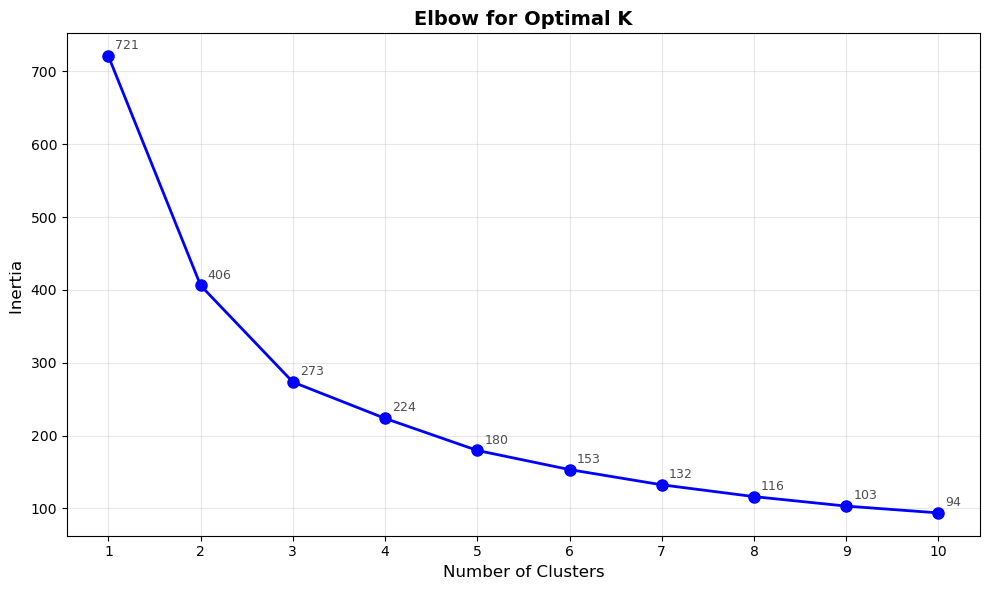

In [10]:
#plotting elbo method
print("="*80)
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Inertia ', fontsize=12)
plt.title('Elbow for Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)

for k, inertia in zip(K_range, inertias):
    plt.annotate(f'{inertia:.0f}', 
                xy=(k, inertia), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9,
                alpha=0.7)
    plt.tight_layout()
#we can see from the plot the the optimal number of clusters is 3

In [11]:
print("="*80)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

cluster_labels = kmeans.labels_
print("="*80)

C:\Users\kenne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [12]:

print("="*80)

data_clean_copy = data_clean.copy()
data_clean_copy['Cluster'] = cluster_labels 

print("\nCluster sizes:")
for i in range(optimal_k):
    count = np.sum(cluster_labels == i)
    percentage = (count / len(cluster_labels)) * 100
    print(f"  Cluster {i+1}: {count:3d} countries ({percentage:.1f}%)")


cluster_means = data_clean_copy.groupby('Cluster')[feature_columns].mean()
for i in range(optimal_k):
    print(f"\nCluster {i+1} - Mean values:")
    print(cluster_means.loc[i]) 
    print("-" * 60)


Cluster sizes:
  Cluster 1:  52 countries (50.5%)
  Cluster 2:   3 countries (2.9%)
  Cluster 3:  48 countries (46.6%)

Cluster 1 - Mean values:
rgdpo    999907.199594
pop          25.062214
emp          11.021276
avh        1695.306154
hc            3.313039
ck            0.049470
ctfp          0.813165
Name: 0, dtype: float64
------------------------------------------------------------

Cluster 2 - Mean values:
rgdpo    2.131609e+07
pop      1.060268e+03
emp      4.985662e+02
avh      2.186780e+03
hc       2.888393e+00
ck       9.362487e-01
ctfp     6.252490e-01
Name: 1, dtype: float64
------------------------------------------------------------

Cluster 3 - Mean values:
rgdpo    571413.031311
pop          41.455992
emp          16.667666
avh        2093.383750
hc            2.557454
ck            0.029448
ctfp          0.493663
Name: 2, dtype: float64
------------------------------------------------------------


In [13]:
print("="*80)
# Interpreting clusters
cluster_names = {}
optimal_k = 3

for i in range(optimal_k):
    cluster_names[i] = f"Cluster {i+1}"
    
    print(f"\n{cluster_names[i]}")
    print(f"  Cluster size: {np.sum(cluster_labels == i)} countries")

# Show sample countries from each cluster
data_clean_copy['Cluster_Name'] = data_clean_copy['Cluster'].map(cluster_names)

for i in range(optimal_k):
    cluster_countries = data_clean_copy[data_clean_copy['Cluster'] == i]['country'].values
    print(f"\n{cluster_names[i]}:")
    print(f"  Total: {len(cluster_countries)} countries")
    print(f"  Samples: {', '.join(cluster_countries[:100])}")
    
print('='*80)


Cluster 1
  Cluster size: 52 countries

Cluster 2
  Cluster size: 3 countries

Cluster 3
  Cluster size: 48 countries

Cluster 1:
  Total: 52 countries
  Samples: Argentina, Australia, Austria, Belgium, Bulgaria, Canada, Switzerland, Chile, Cyprus, Czechia, Germany, Denmark, Ecuador, Egypt, Spain, Estonia, Finland, France, Gabon, United Kingdom, Greece, China, Hong Kong SAR, Croatia, Hungary, Ireland, Iraq, Iceland, Israel, Italy, Japan, Kazakhstan, Republic of Korea, Lithuania, Luxembourg, Latvia, Mexico, Malta, Mauritius, Netherlands, Norway, New Zealand, Poland, Portugal, Romania, Singapore, Slovakia, Slovenia, Sweden, Trinidad and Tobago, Türkiye, Taiwan, Uruguay

Cluster 2:
  Total: 3 countries
  Samples: China, India, United States

Cluster 3:
  Total: 48 countries
  Samples: Angola, Albania, Armenia, Burkina Faso, Bahrain, Bolivia (Plurinational State of), Brazil, Botswana, Côte d'Ivoire, Cameroon, Colombia, Costa Rica, Dominican Republic, Guatemala, Indonesia, Iran (Islamic Re

2D Visulisation of Clusters
cluster 1 = red
Cluster 2 = green
cluster 3 = blue
  Variance explained by PCA: 52.1%
  Total variance explained: 80.2%


Text(0.5, 1.0, 'K-Means Clustering Results (PCA Projection)')

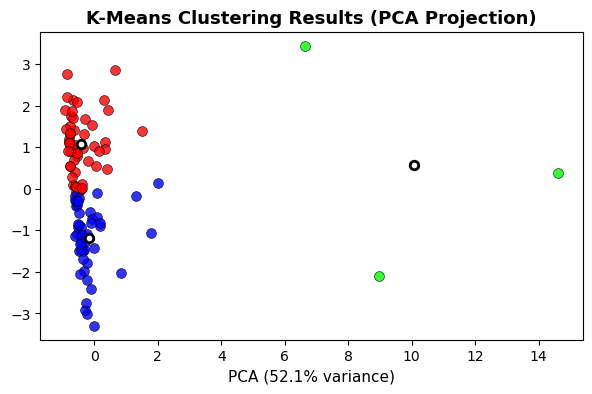

In [16]:
print("2D Visulisation of Clusters")
print("="*80)

print('cluster 1 = red')
print('Cluster 2 = green')
print('cluster 3 = blue')

#We apply pca to visulise in 2d
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)


print(f"  Variance explained by PCA: {pca.explained_variance_ratio_[0]:.1%}")

print(f"  Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")


fig, axes = plt.subplots(1, figsize=(7, 4))

colors = ['#FF0000FF', '#00FF00', '#0000FF']

for i in range(optimal_k):
    mask = cluster_labels == i
    axes.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=colors[i], label=cluster_names[i], 
                   s=50, alpha=0.8, edgecolors='black', linewidth=0.5)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
axes.scatter(centers_pca[:, 0], centers_pca[:, 1], 
               c='white', marker='.', s=150, edgecolors='black', 
               linewidth=2, label='Centroids', zorder=5)

axes.set_xlabel(f'PCA ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
axes.set_title('K-Means Clustering Results (PCA Projection)', fontsize=13, fontweight='bold')

In [17]:
fig.savefig('means_visualization.png')